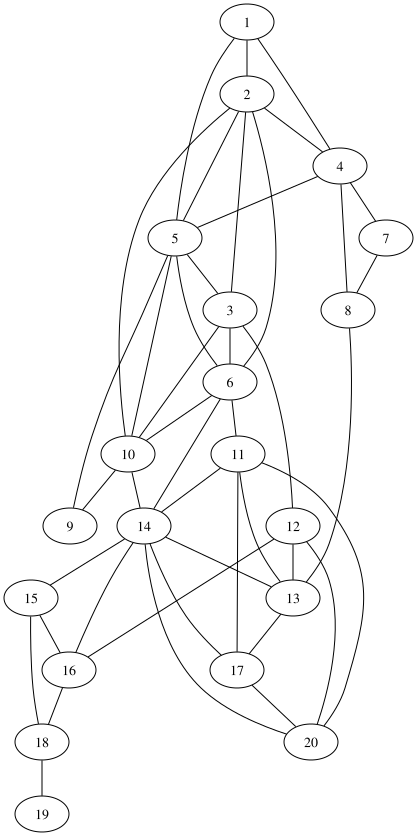

In [87]:

# Importação do grafo
from networkx import nx_agraph
from graphviz import Source

# Carregar o grafo usando NetworkX
graph = nx_agraph.read_dot('./graph.dot')

# Converter o grafo para o formato DOT
graph_dot = nx_agraph.to_agraph(graph)

# Imprime na tela
source = Source(graph_dot.to_string())
source
# source.view()  # Abre o visualizador padrão do sistema operacional



In [104]:
COLORS = ["red", "green", "blue", "orange", "purple", "cyan", "yellow", "magenta"]


def get_max_saturation_node(no_color_nodes, graph):
    max_saturation = -1
    max_node = None
    for node in no_color_nodes:
        neighbor_colors = set()
        for neighbor in graph.neighbors(node):
            neighbor_color = graph.nodes[neighbor].get('color')
            if neighbor_color is not None:
                neighbor_colors.add(neighbor_color)
        saturation = len(neighbor_colors)
        if saturation > max_saturation:
            max_saturation = saturation
            max_node = node
    return max_node


def get_available_color(node, graph, used_colors):
    neighbor_colors = set()
    for neighbor in graph.neighbors(node):
        neighbor_color = graph.nodes[neighbor].get('color')
        if neighbor_color is not None:
            neighbor_colors.add(neighbor_color)
    for color in used_colors:
        if color not in neighbor_colors:
            return color
    new_color = COLORS[len(used_colors)]
    return new_color


no_color_nodes = list(graph.nodes())
used_colors = []

while no_color_nodes:
    node = get_max_saturation_node(no_color_nodes, graph)
    color = get_available_color(node, graph, used_colors)

    if color not in used_colors:
        used_colors.append(color)

    graph.nodes[node]['color'] = color
    print("Node:", node, " | Selected color:", color)
    no_color_nodes.remove(node)

print()
print("Total colors used:", len(used_colors))

Node: 2  | Selected color: red
Node: 5  | Selected color: green
Node: 3  | Selected color: blue
Node: 6  | Selected color: orange
Node: 10  | Selected color: purple
Node: 14  | Selected color: red
Node: 1  | Selected color: blue
Node: 4  | Selected color: orange
Node: 8  | Selected color: green
Node: 11  | Selected color: green
Node: 13  | Selected color: blue
Node: 17  | Selected color: orange
Node: 20  | Selected color: blue
Node: 7  | Selected color: red
Node: 9  | Selected color: red
Node: 15  | Selected color: green
Node: 16  | Selected color: blue
Node: 18  | Selected color: red
Node: 12  | Selected color: red
Node: 19  | Selected color: green

Total colors used: 5


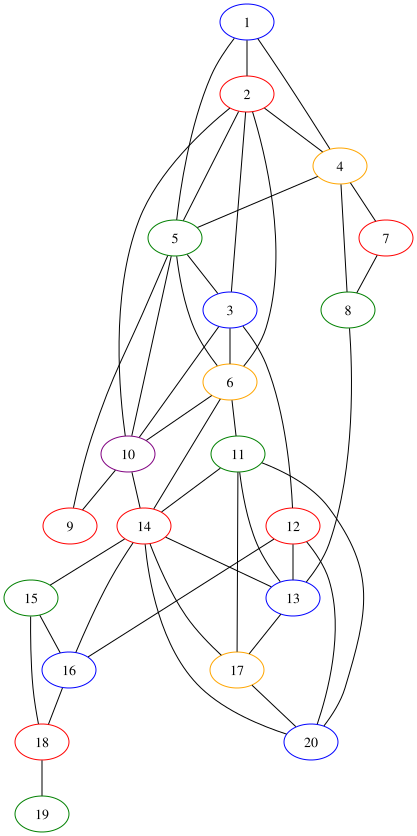

In [105]:
def print_graph(graph):
    graph_dot = nx_agraph.to_agraph(graph)
    source = Source(graph_dot.to_string())
    return source

print_graph(graph)